# Model Comparison

This notebook compares the machine learning and deep learning models
trained in the previous notebooks:

- **Logistic Regression** (ML) - from `05_logistic_regression.ipynb`
- **LSTM** (DL) - from `06_lstm_model.ipynb`

It loads the evaluation metrics that each model already saved, compares
them using **accuracy** (and the full metric set), and visualizes the
results with **matplotlib** — without re-training any model.

**Metric sources:**
- `reports/metrics/logistic_regression_metrics.csv`
- `reports/metrics/lstm_metrics.csv`

In [1]:
from pathlib import Path


def find_project_root(start_path: Path) -> Path:
    """
    Find project root folder by checking for requirements.txt and data folder.
    This works even if notebook runs from notebooks/ or project root.
    """
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

LR_METRICS_PATH = METRICS_DIR / "logistic_regression_metrics.csv"
LSTM_METRICS_PATH = METRICS_DIR / "lstm_metrics.csv"

print("Project root:", PROJECT_ROOT)
print("Logistic Regression metrics:", LR_METRICS_PATH)
print("LSTM metrics:", LSTM_METRICS_PATH)
print("Figures folder:", FIGURES_DIR)

Project root: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05
Logistic Regression metrics: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics/logistic_regression_metrics.csv
LSTM metrics: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics/lstm_metrics.csv
Figures folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures


## Import libraries

The same libraries used by the model notebooks are imported here:
`pandas`, `numpy`, and `matplotlib.pyplot`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Load saved model metrics

Each model notebook (`05_logistic_regression.ipynb` and
`06_lstm_model.ipynb`) computes evaluation metrics and saves them to a
CSV file inside `reports/metrics/`. This notebook loads those files so
the models can be compared without re-training them.

In [3]:
if not LR_METRICS_PATH.exists():
    raise FileNotFoundError(
        f"Logistic Regression metrics not found at: {LR_METRICS_PATH}\n"
        "Please run 05_logistic_regression.ipynb first."
    )

if not LSTM_METRICS_PATH.exists():
    raise FileNotFoundError(
        f"LSTM metrics not found at: {LSTM_METRICS_PATH}\n"
        "Please run 06_lstm_model.ipynb first."
    )

lr_metrics = pd.read_csv(LR_METRICS_PATH)
lstm_metrics = pd.read_csv(LSTM_METRICS_PATH)

print("Model metrics loaded successfully.")
print("Logistic Regression metrics shape:", lr_metrics.shape)
print("LSTM metrics shape:", lstm_metrics.shape)

print("\nLogistic Regression metrics columns:")
print(lr_metrics.columns.tolist())

print("\nLSTM metrics columns:")
print(lstm_metrics.columns.tolist())

display(lr_metrics)
display(lstm_metrics)

Model metrics loaded successfully.
Logistic Regression metrics shape: (1, 12)
LSTM metrics shape: (1, 12)

Logistic Regression metrics columns:
['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'fake_precision', 'fake_recall', 'fake_f1', 'real_precision', 'real_recall', 'real_f1']

LSTM metrics columns:
['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'fake_precision', 'fake_recall', 'fake_f1', 'real_precision', 'real_recall', 'real_f1']


,model,accuracy,precision,recall,f1_score,roc_auc,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,Logistic Regression,0.987212,0.98724,0.987212,0.987207,0.998966,0.990696,0.98129,0.985971,0.98432,0.992215,0.988252


,model,accuracy,precision,recall,f1_score,roc_auc,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,LSTM,0.972762,0.973286,0.972762,0.972712,0.98905,0.98925,0.950852,0.969671,0.959799,0.991272,0.975281


## Combine metrics into a single comparison DataFrame

Both metrics files share the same column structure, so they can be
stacked into one DataFrame for a side-by-side comparison.

In [4]:
comparison_df = pd.concat(
    [lr_metrics, lstm_metrics],
    ignore_index=True
)

# Keep only the model name and core metrics for comparison
core_columns = [
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]

comparison_summary = comparison_df[core_columns].copy()

# Round numeric columns for display
numeric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]

comparison_summary[numeric_columns] = comparison_summary[
    numeric_columns
].round(4)

print("Model comparison summary")
print("=======================")
display(comparison_summary)

Model comparison summary


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9872,0.9872,0.9872,0.9872,0.999
1,LSTM,0.9728,0.9733,0.9728,0.9727,0.989


## Accuracy comparison

Accuracy is the primary metric requested for comparing the two models.
Both models are evaluated on the same test set, so their accuracy values
are directly comparable.

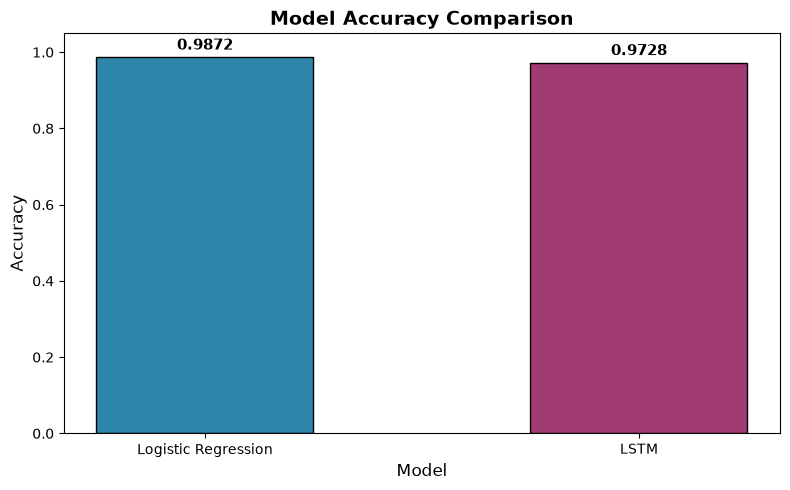

Accuracy comparison graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/model_accuracy_comparison.png

Best accuracy: Logistic Regression with accuracy = 0.9872


In [5]:
plt.figure(figsize=(8, 5))

models = comparison_df["model"].tolist()
accuracies = comparison_df["accuracy"].tolist()

bars = plt.bar(
    models,
    accuracies,
    color=["#2E86AB", "#A23B72"],
    edgecolor="black",
    width=0.5
)

plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{accuracy:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

accuracy_comparison_path = FIGURES_DIR / "model_accuracy_comparison.png"
plt.savefig(accuracy_comparison_path, dpi=150)
plt.show()

print("Accuracy comparison graph saved to:", accuracy_comparison_path)

best_accuracy_row = comparison_df.loc[
    comparison_df["accuracy"].idxmax()
]

print(
    f"\nBest accuracy: {best_accuracy_row['model']} "
    f"with accuracy = {best_accuracy_row['accuracy']:.4f}"
)

## Full metrics comparison (bar chart)

Comparing all core metrics at once gives a fuller picture than accuracy
alone.

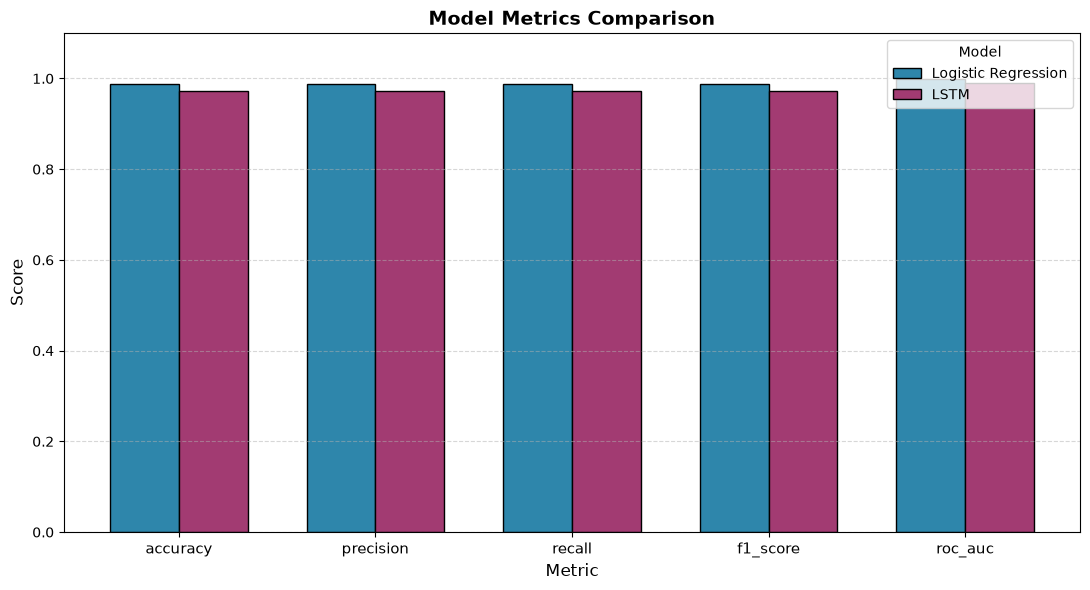

Full metrics comparison graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/model_full_metrics_comparison.png


In [6]:
metrics_to_compare = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
]

num_metrics = len(metrics_to_compare)
num_models = len(comparison_df)
bar_width = 0.35
x = np.arange(num_metrics)

plt.figure(figsize=(11, 6))

model_colors = ["#2E86AB", "#A23B72"]

for index, model_name in enumerate(models):
    model_values = [
        comparison_df.loc[
            comparison_df["model"] == model_name, metric
        ].values[0]
        for metric in metrics_to_compare
    ]

    plt.bar(
        x + (index - 0.5) * bar_width,
        model_values,
        width=bar_width,
        label=model_name,
        color=model_colors[index],
        edgecolor="black"
    )

plt.xticks(
    x,
    metrics_to_compare,
    fontsize=11
)
plt.title(
    "Model Metrics Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title="Model")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

full_metrics_path = FIGURES_DIR / "model_full_metrics_comparison.png"
plt.savefig(full_metrics_path, dpi=150)
plt.show()

print("Full metrics comparison graph saved to:", full_metrics_path)

## ROC-AUC comparison

ROC-AUC measures how well each model ranks Fake vs Real news. The
probability scores used by each model are already saved inside the
per-model metrics CSVs.

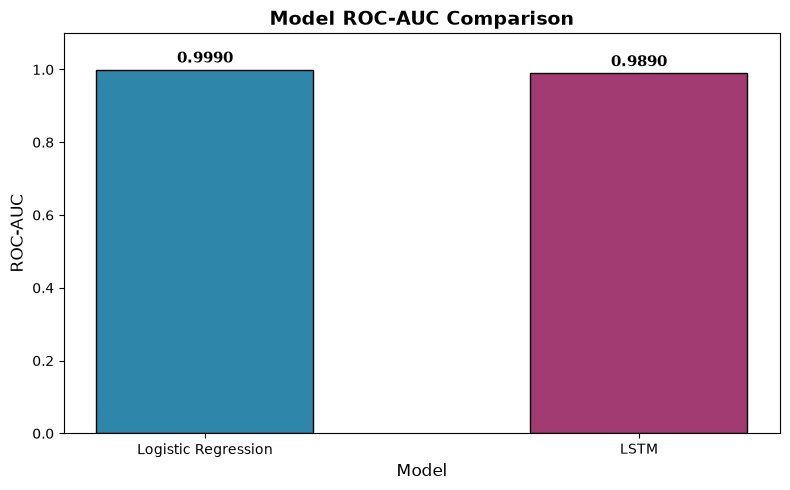

ROC-AUC comparison graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/model_roc_auc_comparison.png


In [7]:
plt.figure(figsize=(8, 5))

roc_values = comparison_df.set_index("model")["roc_auc"].tolist()

bars = plt.bar(
    models,
    roc_values,
    color=["#2E86AB", "#A23B72"],
    edgecolor="black",
    width=0.5
)

plt.title("Model ROC-AUC Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("ROC-AUC", fontsize=12)
plt.ylim(0, 1.1)

for bar, roc_value in zip(bars, roc_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{roc_value:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

roc_comparison_path = FIGURES_DIR / "model_roc_auc_comparison.png"
plt.savefig(roc_comparison_path, dpi=150)
plt.show()

print("ROC-AUC comparison graph saved to:", roc_comparison_path)

## Per-class (Fake / Real) metrics comparison

This compares how each model performs on the Fake News class
(`fake_precision`, `fake_recall`, `fake_f1`) and the Real News class
(`real_precision`, `real_recall`, `real_f1`).

Per-class metrics comparison


,model,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,Logistic Regression,0.9907,0.9813,0.9860,0.9843,0.9922,0.9883
1,LSTM,0.9893,0.9509,0.9697,0.9598,0.9913,0.9753


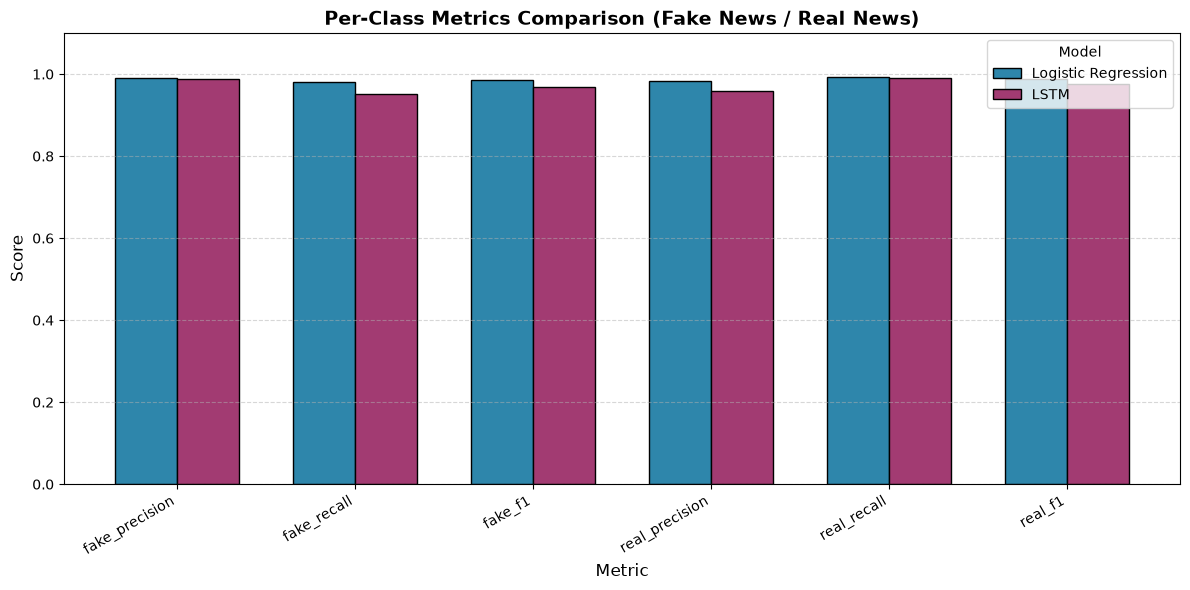

Per-class comparison graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/model_per_class_comparison.png


In [8]:
class_metric_columns = [
    "fake_precision",
    "fake_recall",
    "fake_f1",
    "real_precision",
    "real_recall",
    "real_f1",
]

class_comparison = comparison_df[
    ["model"] + class_metric_columns
].copy()

class_comparison[class_metric_columns] = class_comparison[
    class_metric_columns
].round(4)

print("Per-class metrics comparison")
print("===========================")
display(class_comparison)

plt.figure(figsize=(12, 6))

num_class_metrics = len(class_metric_columns)
x = np.arange(num_class_metrics)
bar_width = 0.35

model_colors = ["#2E86AB", "#A23B72"]

for index, model_name in enumerate(models):
    model_values = [
        comparison_df.loc[
            comparison_df["model"] == model_name, metric
        ].values[0]
        for metric in class_metric_columns
    ]

    plt.bar(
        x + (index - 0.5) * bar_width,
        model_values,
        width=bar_width,
        label=model_name,
        color=model_colors[index],
        edgecolor="black"
    )

plt.xticks(
    x,
    class_metric_columns,
    rotation=30,
    ha="right",
    fontsize=10
)
plt.title(
    "Per-Class Metrics Comparison (Fake News / Real News)",
    fontsize=14,
    fontweight="bold"
)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title="Model")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

class_comparison_path = FIGURES_DIR / "model_per_class_comparison.png"
plt.savefig(class_comparison_path, dpi=150)
plt.show()

print("Per-class comparison graph saved to:", class_comparison_path)

## Save combined comparison summary

The combined comparison is saved to `reports/metrics/` so other
notebooks or reports can reuse the ranking without re-running this one.

In [9]:
comparison_output_path = METRICS_DIR / "model_comparison_summary.csv"

comparison_df.to_csv(comparison_output_path, index=False)

print("Comparison summary saved to:", comparison_output_path)

display(comparison_df)

Comparison summary saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics/model_comparison_summary.csv


,model,accuracy,precision,recall,f1_score,roc_auc,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1
0,Logistic Regression,0.987212,0.987240,0.987212,0.987207,0.998966,0.990696,0.981290,0.985971,0.984320,0.992215,0.988252
1,LSTM,0.972762,0.973286,0.972762,0.972712,0.989050,0.989250,0.950852,0.969671,0.959799,0.991272,0.975281


## Conclusion

- Logistic Regression and LSTM are both evaluated on the same held-out
  test set.
- Accuracy (and the other metrics) are loaded from the per-model metrics
  CSVs produced in `05_logistic_regression.ipynb` and
  `06_lstm_model.ipynb`.
- The model with the highest accuracy on this dataset is highlighted
  above.
- Pick the model that best balances accuracy, ROC-AUC, and per-class
  recall depending on the deployment goal.